### Etape 1 : Imports et chargement des données

In [73]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Quelques réglages pour que les graphes soient lisibles 
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True

# Chemin vers le fichier propre créé à l'étape 1
proc = Path("C:/Users/USER/Downloads/projet_personnel_fraude_bancaire/data/processed")
df = pd.read_csv(proc/"fraude_clean.csv")

# Aperçu rapide 
print("Taille du dataset (lignes , colonnes) :",df.shape)
df.head() 

Taille du dataset (lignes , colonnes) : (283726, 35)


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v25,v26,v27,v28,amount,class,heure,jour_simule,amount_log1p,is_fraud
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,0,5.014760,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,0,1.305626,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,0,5.939276,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,0,4.824306,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,0,4.262539,0


### Etape 2 : Vue d’ensemble : structure des données

In [75]:
print("Colonnes :")
print(list(df.columns))

print("\nInformations sur les colonnes :")
df.info()

print("\nStatistiques descriptives des colonnes numériques :")
df.describe().T # la transposé

Colonnes :
['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class', 'heure', 'jour_simule', 'amount_log1p', 'is_fraud']

Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 35 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   time          283726 non-null  float64
 1   v1            283726 non-null  float64
 2   v2            283726 non-null  float64
 3   v3            283726 non-null  float64
 4   v4            283726 non-null  float64
 5   v5            283726 non-null  float64
 6   v6            283726 non-null  float64
 7   v7            283726 non-null  float64
 8   v8            283726 non-null  float64
 9   v9            283726 non-null  float64
 10  v10           283726 non-null  float64
 11  v

,count,mean,std,min,25%,50%,75%,max
time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
v1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
v2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
v3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
v4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
v5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
v6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
v7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
v8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
v9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


### Etape 3 : Qualité des données (NA + doublons)

In [77]:
# Valeurs manquantes par colonne
na_counts = df.isna().sum()
print("Valeurs manquantes par colonne (seulement > 0) :")
print (na_counts[na_counts>0])

#Nombre de doublons 
nb_dups = df.duplicated().sum()
print("\nNombre de doublons exacts :" , nb_dups)

# Dataset déja nettoyé !!!

Valeurs manquantes par colonne (seulement > 0) :
Series([], dtype: int64)

Nombre de doublons exacts : 0


### Etape 4 : KPI globaux (indicateurs clés)

In [79]:
n_total = len(df)                      #nombre total des transactions(lignes du DataFrame)
n_fraude = int (df["is_fraud"].sum())  #nbre total des fraudes
taux_fraude = df["is_fraud"].mean()   

montant_total = df["amount"].sum()     # Additionne tous les montants 
montant_moyen = df["amount"].mean()
montant_median = df["amount"].median()

# Affichage des indicateurs de performances (KPI)
print("Nombre total des transactions :", n_total)
print("Nombre de fraude ", n_fraude)
print("Taux de fraude ", format(taux_fraude, ".4%"))
print ("Montant total des transactions ",format(montant_total, ".2f"))
print("Montant moyen :", format(montant_moyen, ".2f"))
print("Montant median :", format(montant_median ,".2f"))

Nombre total des transactions : 283726
Nombre de fraude  473
Taux de fraude  0.1667%
Montant total des transactions  25102001.68
Montant moyen : 88.47
Montant median : 22.00


### Etape 5 : Répartition fraude vs non-fraude

is_fraud
0    283253
1       473
Name: count, dtype: int64

Répartition en % :
is_fraud
0    99.8333
1     0.1667
Name: count, dtype: float64


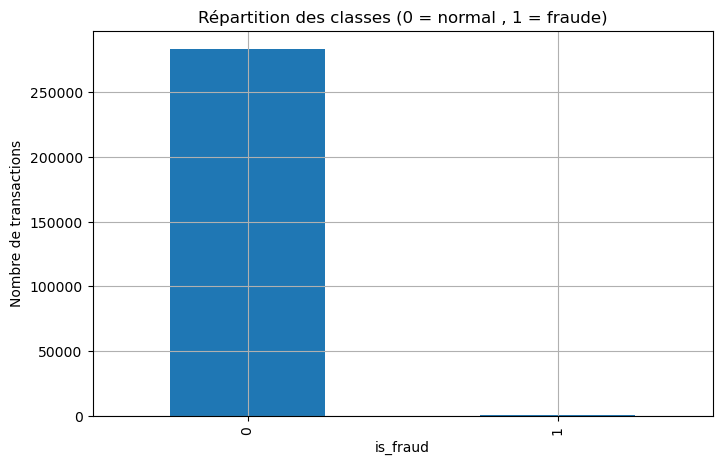

In [81]:
counts = df["is_fraud"].value_counts().sort_index()
print(counts)
print("\nRépartition en % :")
print((counts / counts.sum()*100).round(4))

# Création du graphique en barres
ax = counts.plot (kind ="bar")
ax.set_title ("Répartition des classes (0 = normal , 1 = fraude)")
ax.set_xlabel("is_fraud")
ax.set_ylabel ("Nombre de transactions")
plt.show()

### Etape 6 : Analyse des montants

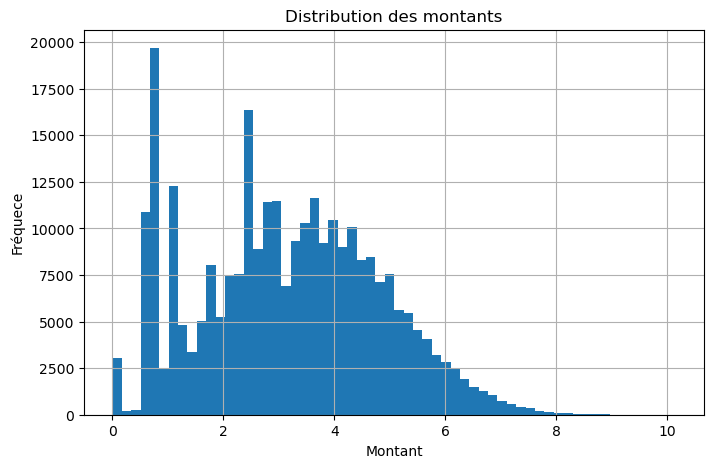

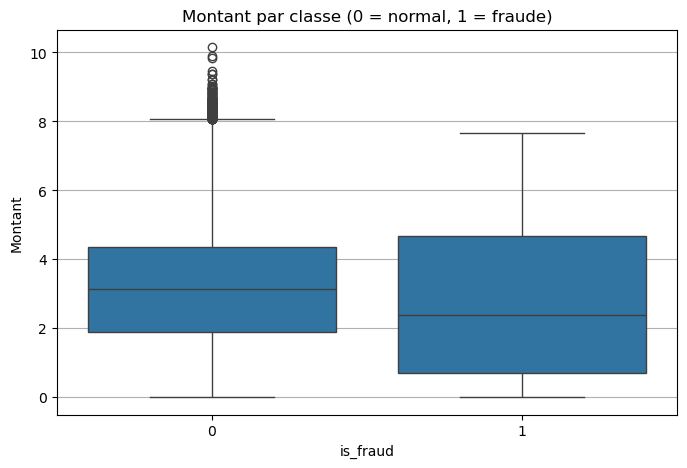

In [94]:
# Histogramme des montants
df["amount_log1p"].plot(kind ="hist" , bins =60)
plt.title("Distribution des montants")
plt.xlabel("Montant")
plt.ylabel("Fréquece")
plt.show()

# Comparaison des montants pour fraude vs non-fraude 
sns.boxplot (data=df , x="is_fraud" , y="amount_log1p")
plt.title ("Montant par classe (0 = normal, 1 = fraude)")
plt.xlabel("is_fraud")
plt.ylabel("Montant")
plt.show()

### Etape 7 : Taux de fraude par heure

heure
0     0.078462
1     0.237643
2     1.451028
3     0.487525
4     1.043557
5     0.368139
6     0.220480
7     0.317987
8     0.087959
9     0.101478
10    0.048344
11    0.315833
12    0.110548
13    0.110944
14    0.139225
15    0.158788
16    0.134179
17    0.173590
18    0.165104
19    0.122061
20    0.107752
21    0.090760
22    0.058525
23    0.156207
Name: is_fraud, dtype: float64


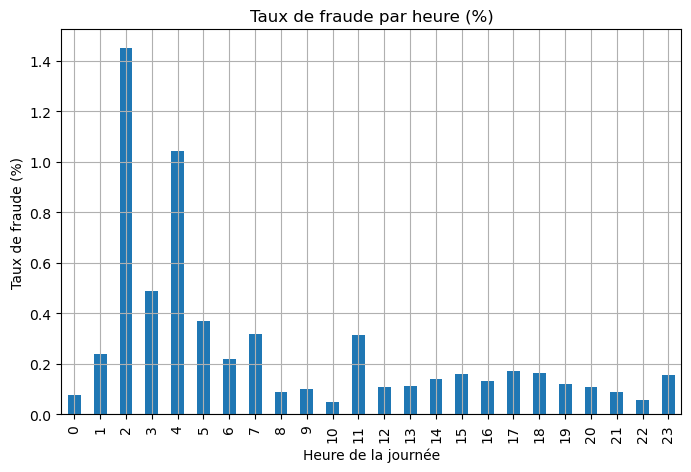

In [105]:
if "heure" in df.columns :
    taux_par_heure = df.groupby("heure")["is_fraud"].mean()*100 #en % 
    print (taux_par_heure)

    taux_par_heure.plot(kind = "bar")
    plt.title("Taux de fraude par heure (%)")
    plt.xlabel("Heure de la journée")
    plt.ylabel("Taux de fraude (%)")
    plt.show()
else : 
    print("Colonne 'heure' non disponible dans le dataset.")

### Etape 8 : Evolution par "jour simulé"

,jour_simule,nb_tx,nb_faude,taux_fraude,montant_total
0,0,144236,272,0.001886,13062078.60
1,1,139490,201,0.001441,12039923.08


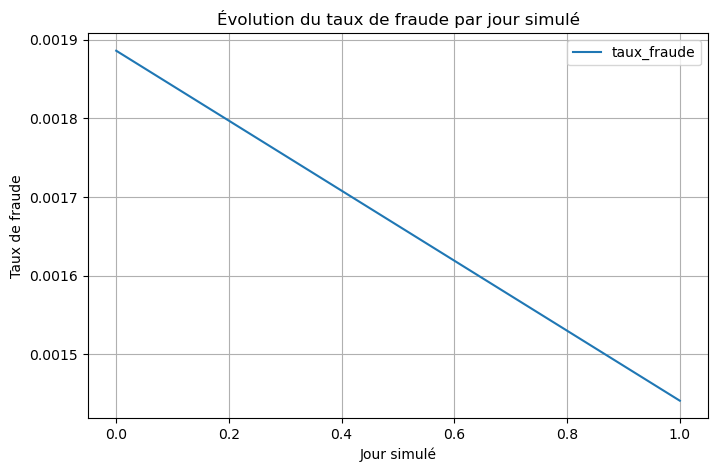

In [125]:
if "jour_simule" in df.columns :
    daily =df.groupby("jour_simule").agg(
        nb_tx=("amount","size"),  #nombre total des transactions 
        nb_faude=("is_fraud" ,"sum"), #nombre de fraudes par jour
        taux_fraude=("is_fraud","mean"),
        montant_total=("amount","sum")
    ).reset_index()  # met le jour_simule comme colonne normale
    display(daily.head()) #Montre les 5 premières lignes du tableau agrégé 

    # Courbe du taux de fraude par jour
    daily.plot(x="jour_simule", y = "taux_fraude", kind ="line")
    plt.title("Évolution du taux de fraude par jour simulé")
    plt.xlabel("Jour simulé")
    plt.ylabel("Taux de fraude")
    plt.show()
else :
    print("Colonne 'jour_simule' non disponible dans le dataset.")


### Etape 9 : Corrélations entre variables 

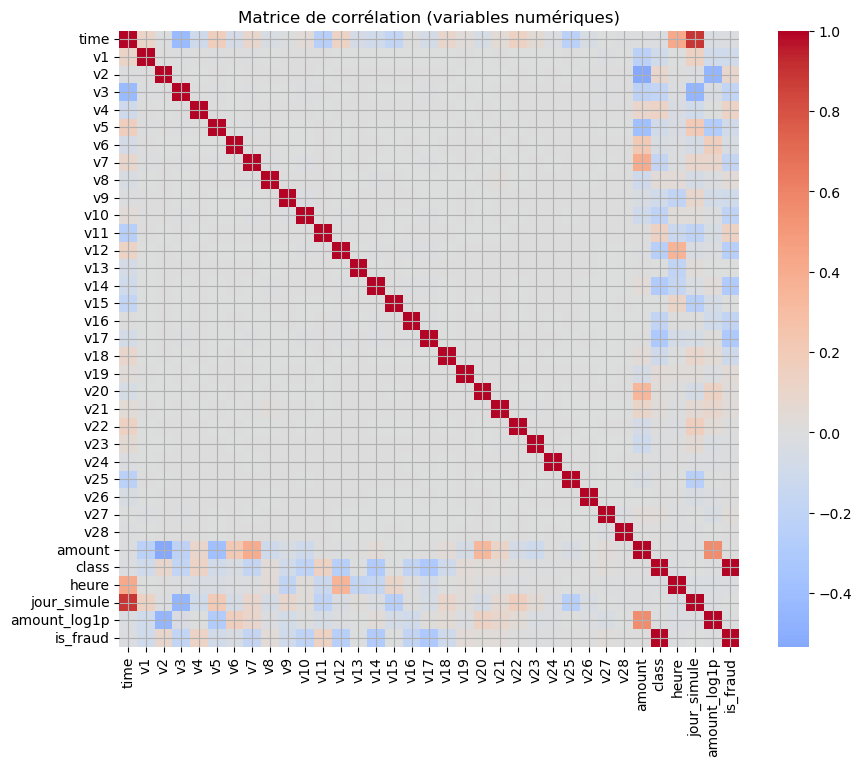

Corrélation avec is_fraud (top 10) :
is_fraud    1.000000
class       1.000000
v11         0.149067
v4          0.129326
v2          0.084624
v19         0.033631
v8          0.033068
v21         0.026357
v27         0.021892
v20         0.021486
Name: is_fraud, dtype: float64


In [140]:
num_df = df.select_dtypes(include=[np.number]).copy() # garde seulement les colonnes numériques | .copy() :crée une copie propre pour éviter les warnings

#calcule la corrélation de Pearson entre toutes les paires de variables numériques
corr = num_df.corr()  

#Afficher une heatmap des corrélations
plt.figure(figsize=(10,8))
sns.heatmap(corr , cmap ="coolwarm", center =0)
plt.title("Matrice de corrélation (variables numériques)")
plt.show()

## Explications :
    #Corrélation = comment 2 variables changent ensemble.
    #rouge = corrélation positive
    #bleu = corrélation négative
    #blanc = proche de zéro (pas de relation)

# Extraire les corrélations avec la cible is_fraud
if "is_fraud" in corr.columns :
    corr_target = corr["is_fraud"].sort_values(ascending=False)
    print("Corrélation avec is_fraud (top 10) :")
    print(corr_target.head(10))

### Etape 10 : Rédiger tes insights (texte)

# Insights principaux - Analyse exploratoire

- Le dataset contient **283726 transactions** dont **473 fraudes**, soit un taux de fraude de **0.1667%**.
- La majorité des transactions ont un montant inférieur à **88.47 €**, mais les fraudes se concentrent autour de **22.00 €** (moyenne / médiane).
- La fraude est **plus fréquente entre 02h et 04h**, ce qui peut indiquer des comportements suspects sur ces plages horaires.
- On observe un **déséquilibre très fort** entre la classe normale (0) et la classe fraude (1), ce qui rend la détection plus difficile.
- Certaines variables (ex : classe, v11…) présentent une corrélation plus forte avec `is_fraud`, ce qui pourrait être utile pour un futur modèle prédictif.
